# RSS Change for a Given Gamma

Examines how the RSS of packets changes while the angle the transmitter faces when it transmits those packets remains constant.

For the `Range Trials/` experiments, the tag didn't move at all, meaning there should be very little change.

In [39]:
from BleFinley import *

tx_a = Transmitter('a', -1.448596, 53.368606, 131.0 + 1.5)
tx_b = Transmitter('b', -1.448626, 53.367865, 131.0 + 1.5)
tx_c = Transmitter('c', -1.450168, 53.368359, 122.0 + 1.5)
tx_e = Transmitter('e', -1.449990, 53.369204, 118.0 + 1.5)

In [40]:
from matplotlib import pyplot as plt

def rss_diff_at_gamma(ble_log :BleLog, gamma :float, packet_gap = 1) -> list[int]:
    rss_at_gamma = ble_log.all_rss_at_gamma(gamma)
    rss_differences = []

    for x in range(len(rss_at_gamma) - packet_gap):
        rss_differences.append(rss_at_gamma[x] - rss_at_gamma[x + packet_gap])

    return rss_differences

## Examine Range Trial 7

Look at the difference in RSS just for gamma = 0, and then look at a combined histogram of all angles from 0-360 degrees.

BleLog | tx: c, no.packets: 1533, time: 86.140s


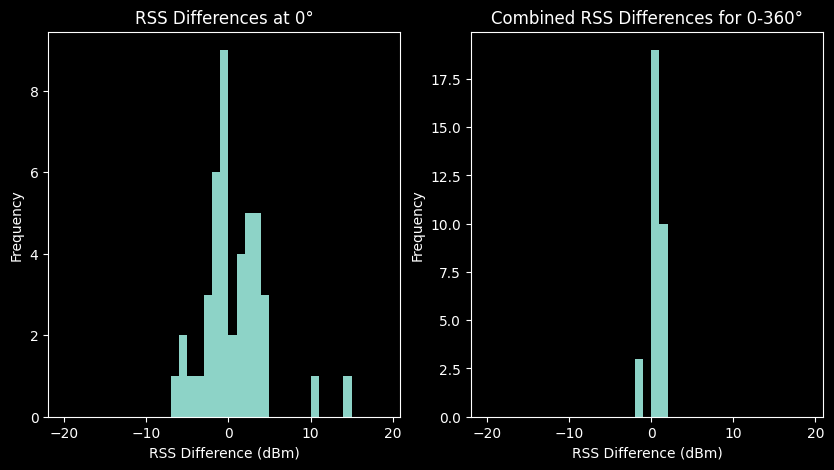

In [41]:
import numpy as np

range_7_log = BleLog("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/7.log", tx_c, None)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("RSS Differences at 0°")
plt.ylabel("Frequency")
plt.xlabel("RSS Difference (dBm)")
plt.hist(rss_diff_at_gamma(range_7_log, 0), bins=np.arange(-20, 20))

plt.subplot(1, 2, 2)
diffs = []

for degree in range(60, 90 - 1):
    diffs.extend(rss_diff_at_gamma(range_7_log, degree))

plt.hist(diffs, bins=np.arange(-20, 20))
plt.title("Combined RSS Differences for 0-360°")
plt.ylabel("Frequency")
plt.xlabel("RSS Difference (dBm)")
plt.show()

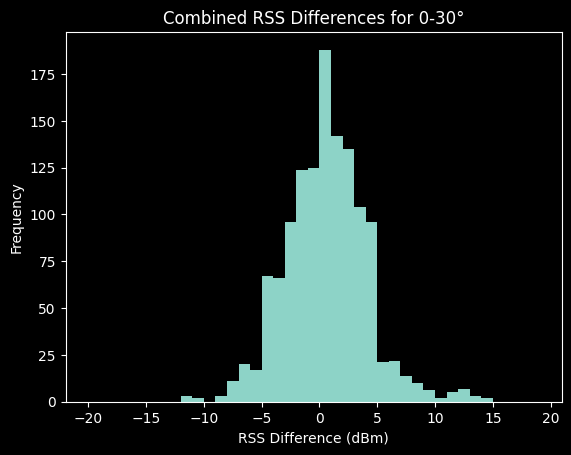

In [42]:
for x in range (0, 30 - 1, 30):
    diffs = []

    for degree in range(x, x+30 - 1):
        diffs.extend(rss_diff_at_gamma(range_7_log, degree))

    plt.hist(diffs, bins=np.arange(-20, 20))
    plt.title(f"Combined RSS Differences for {x}-{x+30}°")
    plt.ylabel("Frequency")
    plt.xlabel("RSS Difference (dBm)")
    plt.show()

In [ ]:
x_axis = [getattr(obj, "rss") for obj in range_7_log.packets]
y_axis = [getattr(obj, "angle") for obj in range_7_log.packets]

plt.plot(y_axis, x_axis, '.')
plt.show()

plt.figure(figsize=(20, 5))
plt.plot([getattr(obj, "rss") for obj in range_7_log.packets])
plt.show()

## Examine All Range Trials Together

Like with the above cell, a histogram of all the RSS differences between sequential packets for a given gamma are calculated, and this is repeated for all nine experiments in the `/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/` folder.f

In [44]:
# parse all range trials into a dictionary
range_logs :dict[str, BleLog] = {}

for file_num in range(1, 9):
    range_logs[f"{file_num}.log"] = BleLog("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/" + str(file_num) + ".log", tx_c, None)

BleLog | tx: c, no.packets: 8314, time: 86.369s
BleLog | tx: c, no.packets: 3108, time: 75.356s
BleLog | tx: c, no.packets: 3208, time: 89.925s
BleLog | tx: c, no.packets: 6502, time: 87.054s
BleLog | tx: c, no.packets: 1518, time: 91.795s
BleLog | tx: c, no.packets: 93, time: 71.421s
BleLog | tx: c, no.packets: 1533, time: 86.140s
BleLog | tx: c, no.packets: 1536, time: 96.692s


### Sequential Packets at Gamma

Take the RSS difference between sequential packets that contain gamma

### Separate Graphs for Every 30 Degrees

Examine the RSS in 30 degree blocks using histograms

#### 0 to 30 Degrees

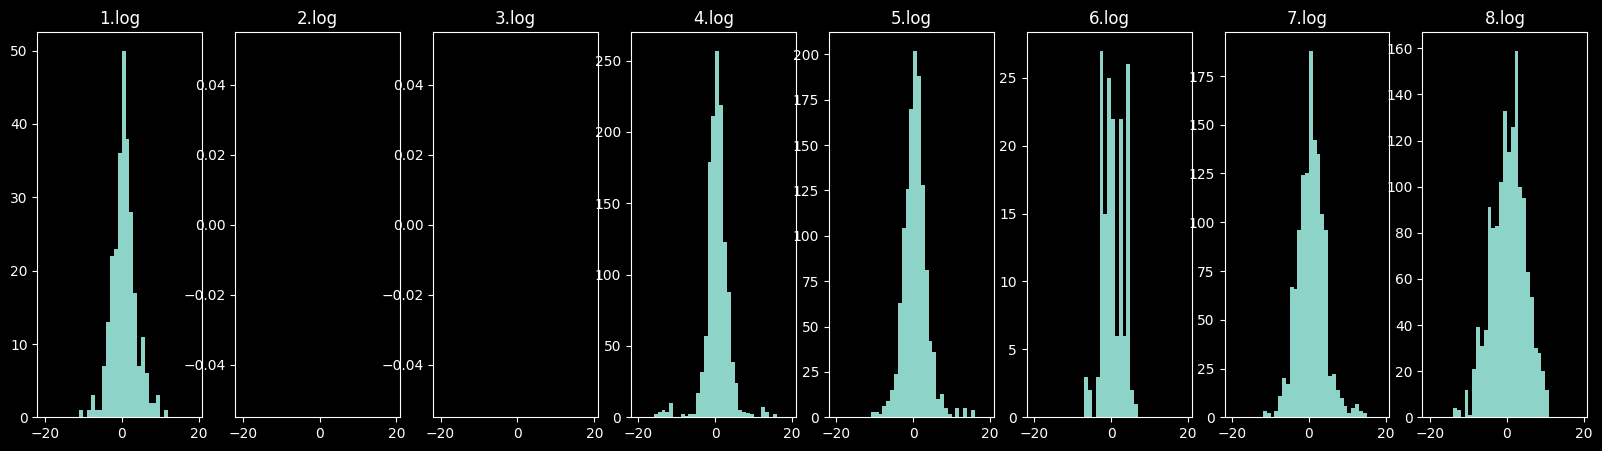

#### 30 to 60 Degrees

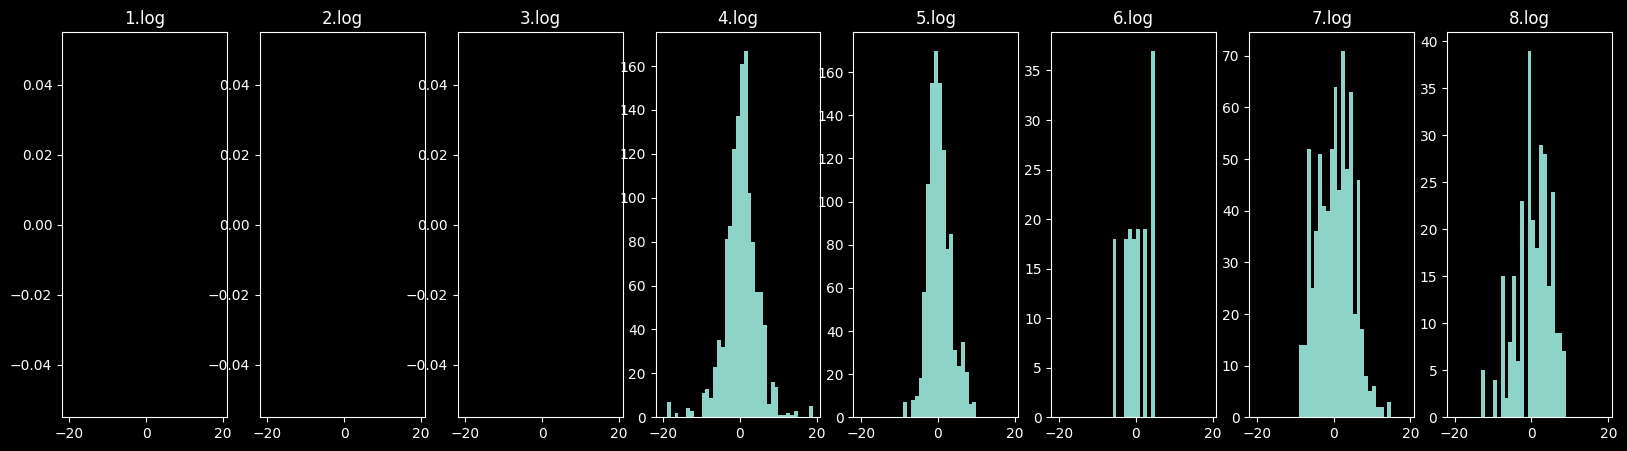

#### 60 to 90 Degrees

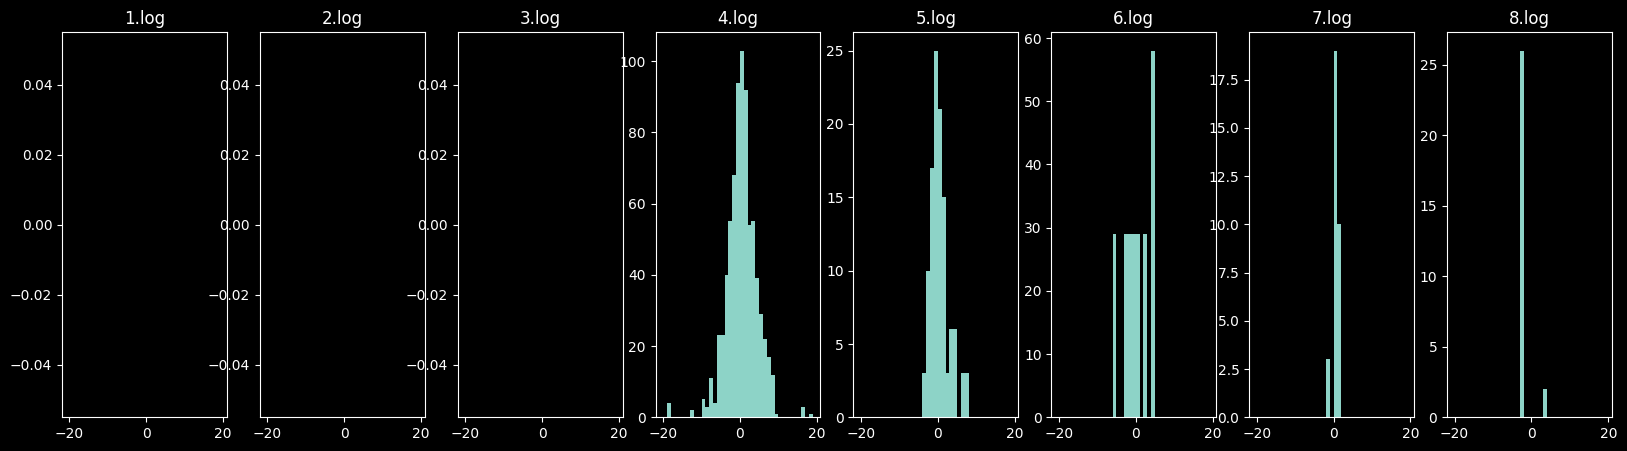

#### 90 to 120 Degrees

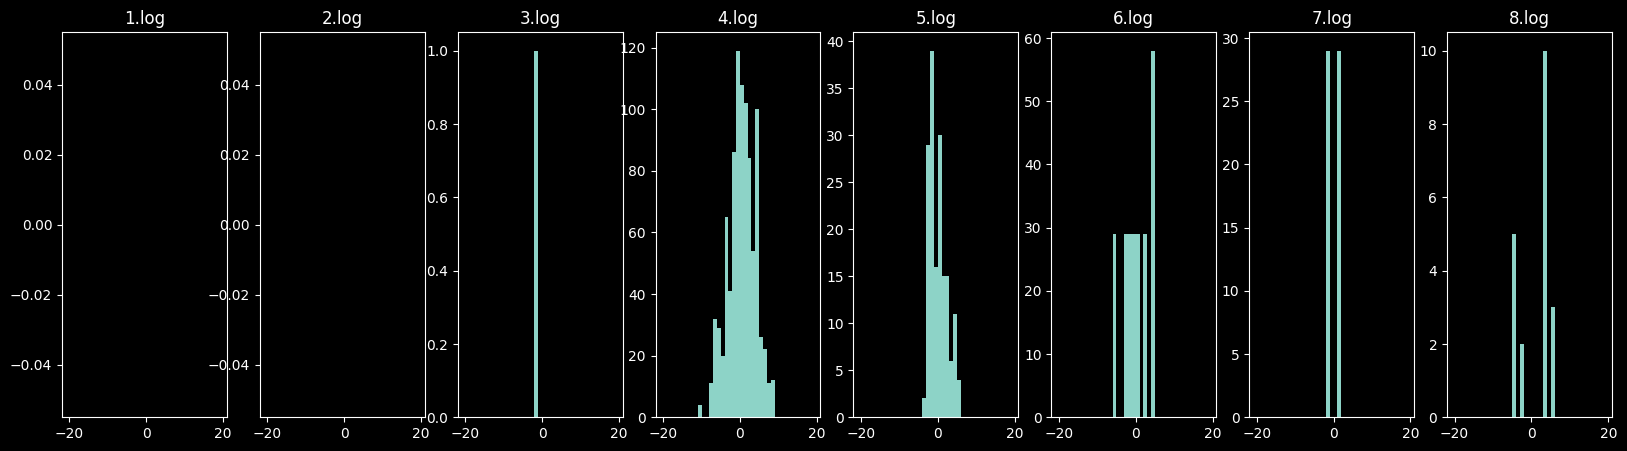

#### 120 to 150 Degrees

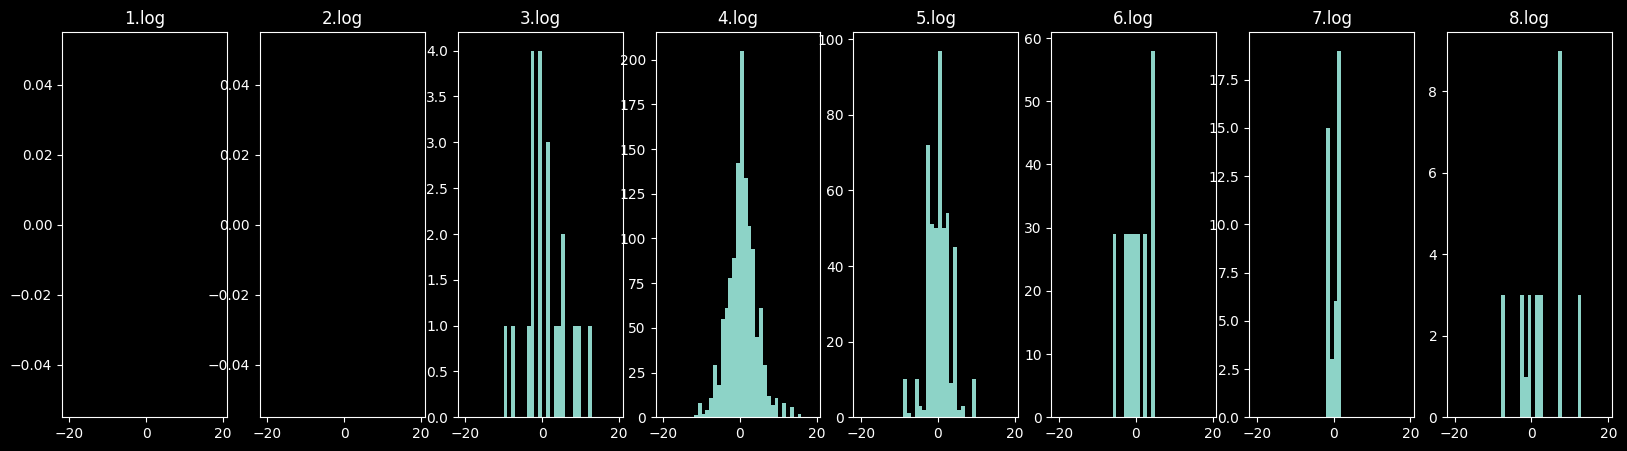

#### 150 to 180 Degrees

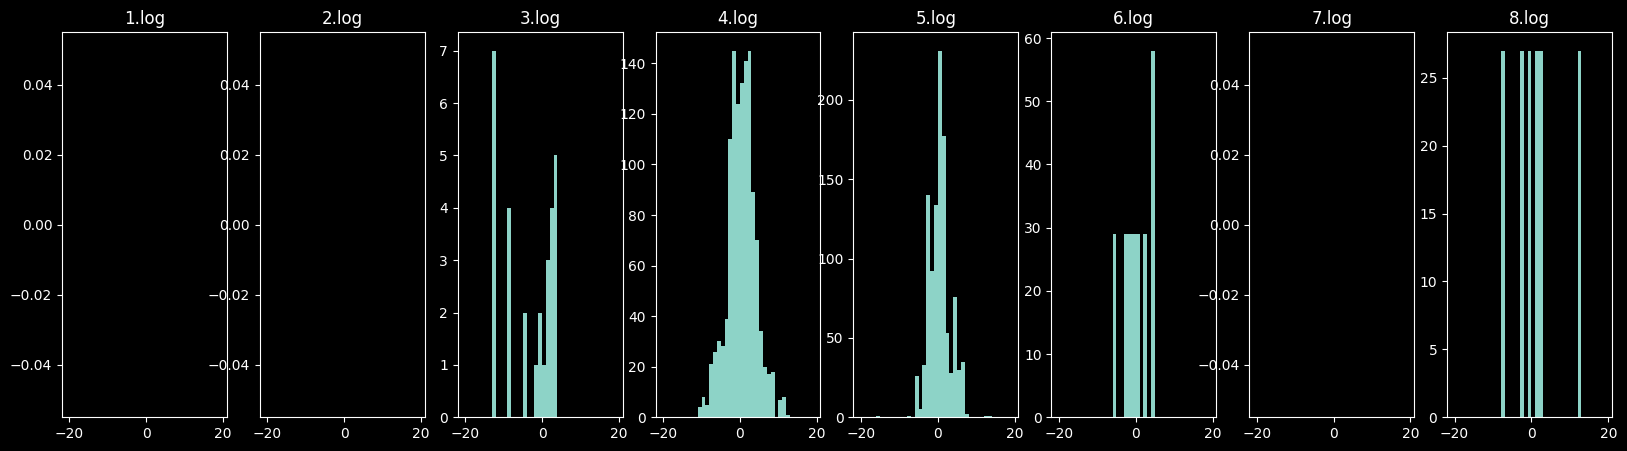

#### 180 to 210 Degrees

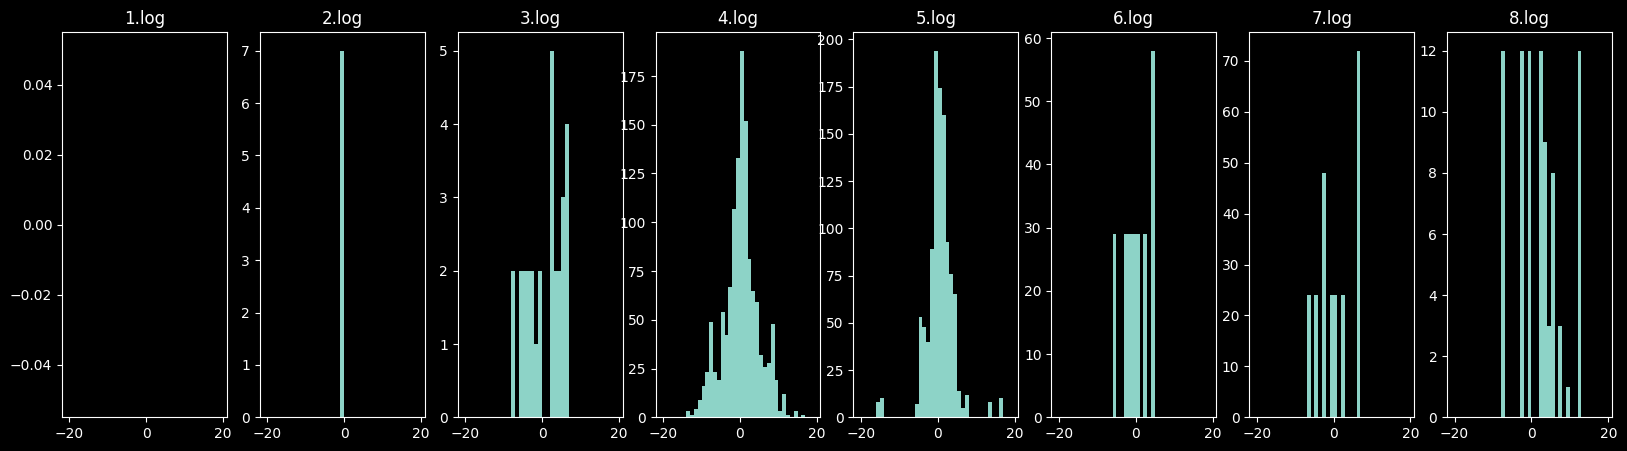

#### 210 to 240 Degrees

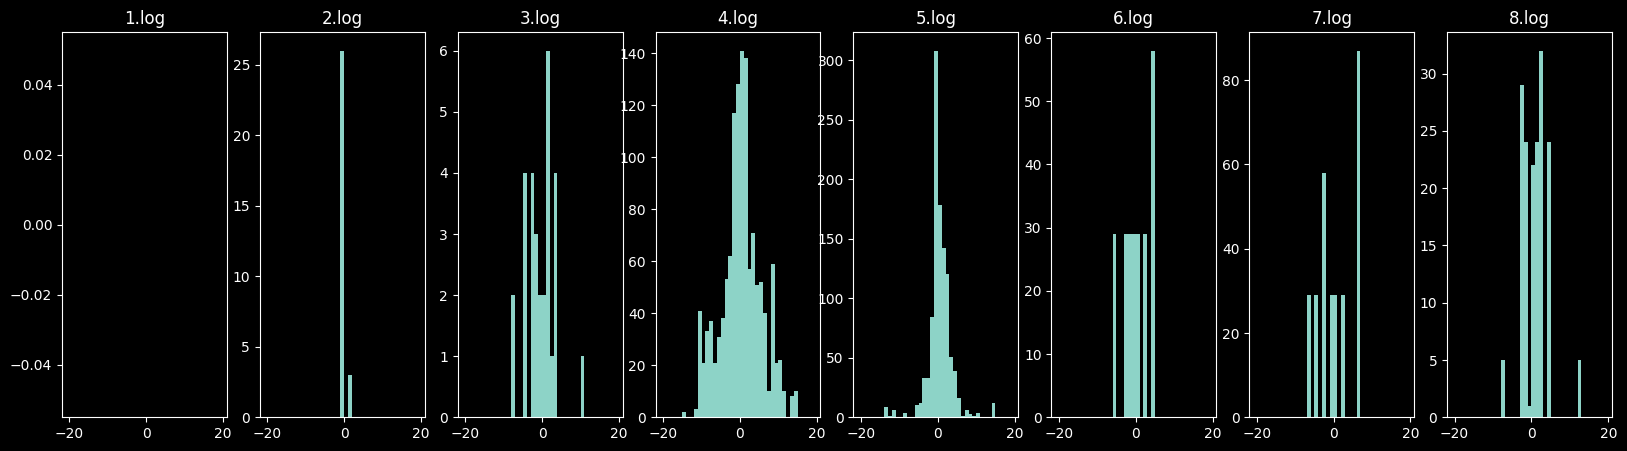

#### 240 to 270 Degrees

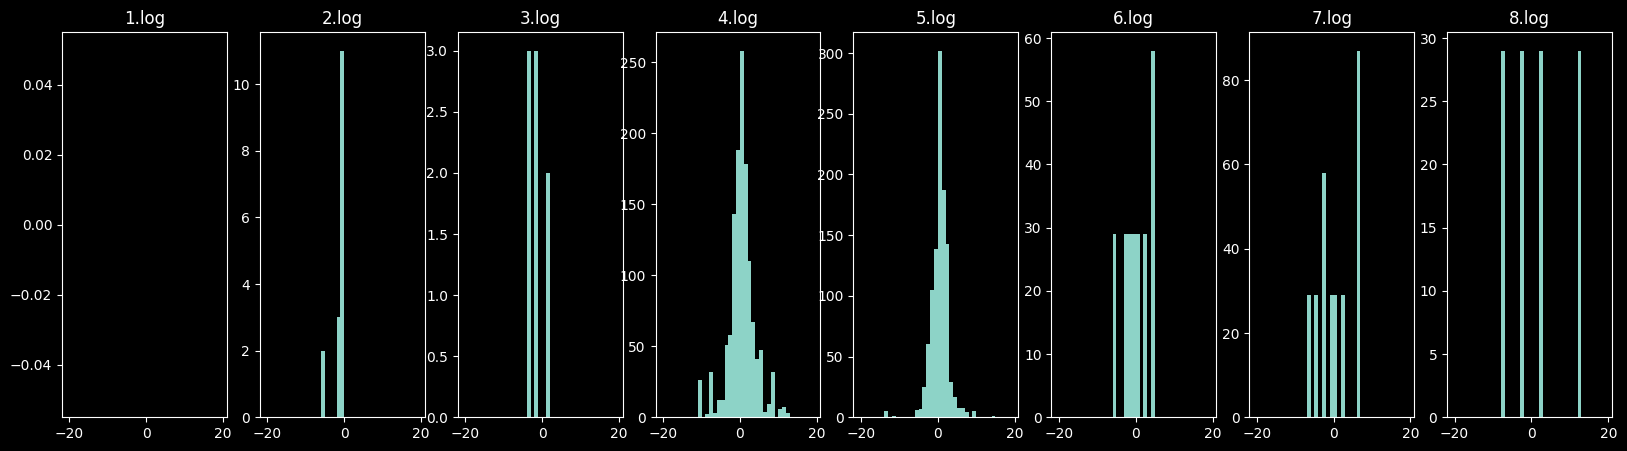

#### 270 to 300 Degrees

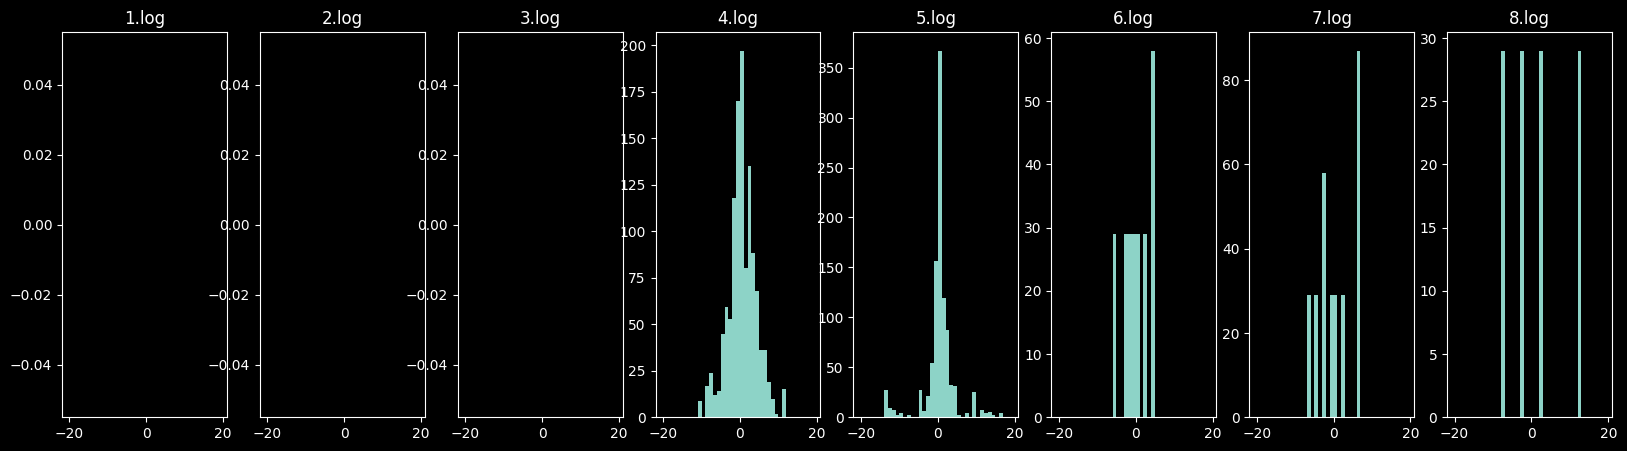

#### 300 to 330 Degrees

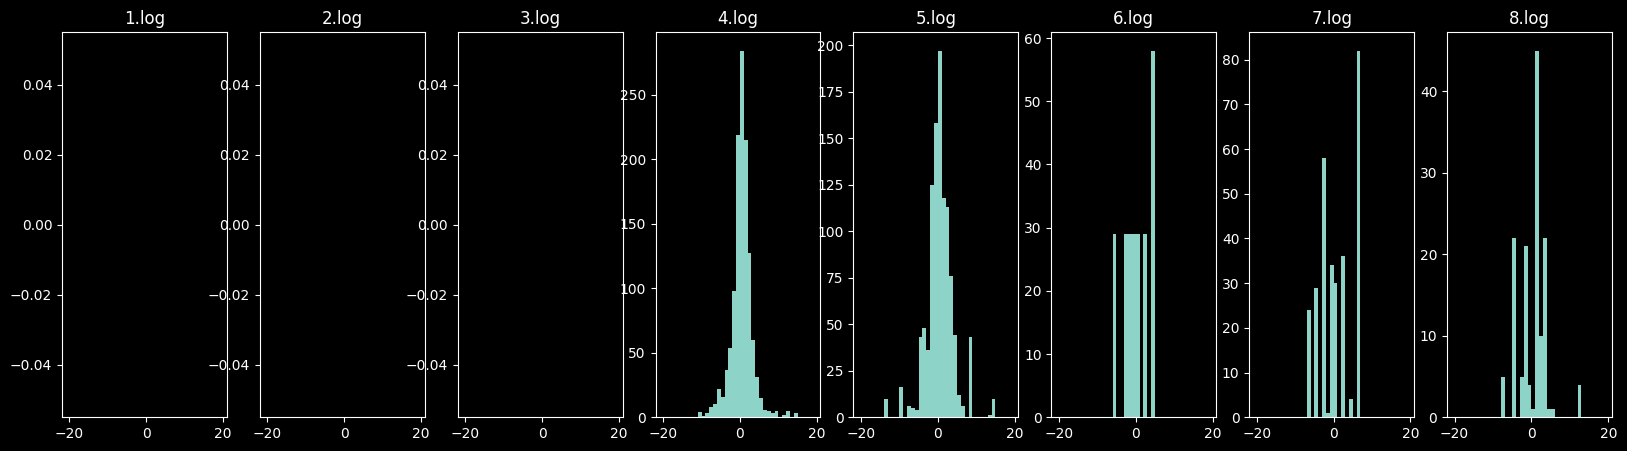

#### 330 to 360 Degrees

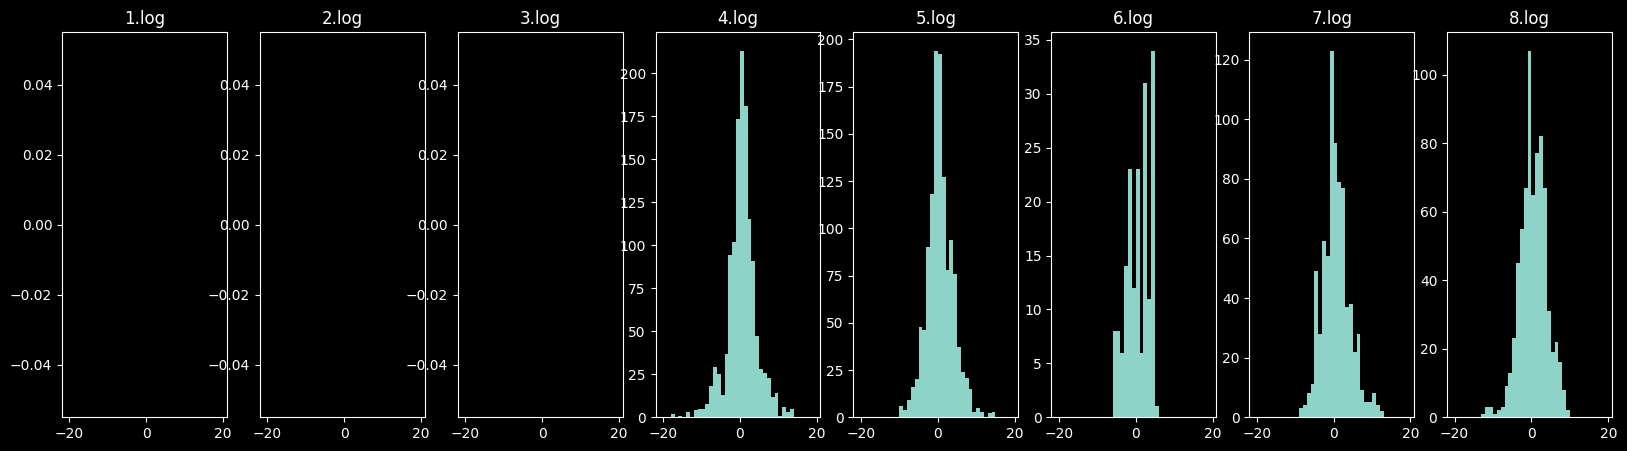

In [53]:
from IPython.display import display, Markdown

for start_angle in range (0, 360, 30):
    display(Markdown(f"#### {start_angle} to {start_angle + 30} Degrees"))
    plt.figure(figsize=(20, 5))
    graph_num = 1

    for name, ble_log in range_logs.items():
        diffs = []

        for angle in range(start_angle, start_angle + 29):
            diffs.extend(rss_diff_at_gamma(ble_log, angle))

        plt.subplot(1, 8, graph_num)
        plt.hist(diffs, bins=np.arange(-20, 20))
        plt.title(name)
        graph_num += 1
    plt.show()

### 0-360 Combined into One Graph

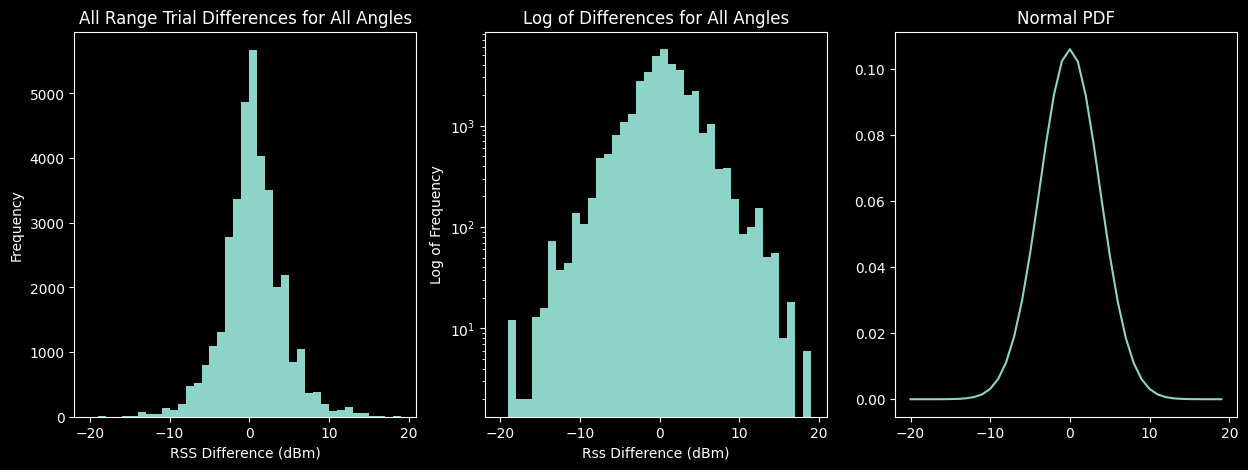

In [47]:
from scipy.stats import norm

range_rss_diffs = []

for range_log in range_logs.values():
    for degree in range(0, 360 - 1):
        range_rss_diffs.extend(rss_diff_at_gamma(range_log, degree))

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(range_rss_diffs, bins=np.arange(-20, 20))
plt.title("All Range Trial Differences for All Angles")
plt.ylabel("Frequency")
plt.xlabel("RSS Difference (dBm)")

plt.subplot(1, 3, 2)
plt.hist(range_rss_diffs, bins=np.arange(-20, 20))
plt.yscale("log")
plt.title("Log of Differences for All Angles")
plt.ylabel("Log of Frequency")
plt.xlabel("Rss Difference (dBm)")

plt.subplot(1, 3, 3)
plt.title("Normal PDF")
plt.plot(np.arange(-20, 20), norm.pdf(np.arange(-20, 20), np.mean(range_rss_diffs), np.std(range_rss_diffs)))
plt.show()

### Difference between Current and Five-Packets-Later

Does the same as above, but instead of measuring the distance between the current and next packet that contain a given gamma, it takes the difference between the current and packet in five-packets time. This simulates what may happen if you took bursts less frequently.

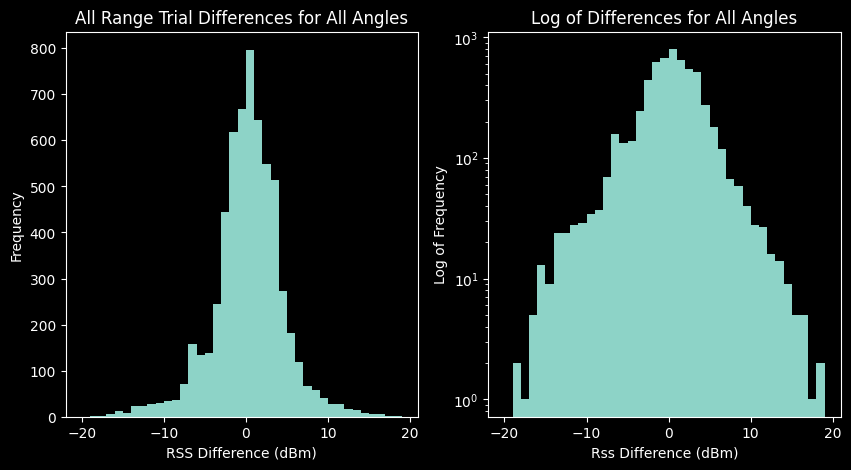

In [48]:
range_rss_diffs = []

for range_log in range_logs.values():
    for degree in range(0, 360 - 1, 5):
        range_rss_diffs.extend(rss_diff_at_gamma(range_log, degree, 5))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(range_rss_diffs, bins=np.arange(-20, 20))
plt.title("All Range Trial Differences for All Angles")
plt.ylabel("Frequency")
plt.xlabel("RSS Difference (dBm)")

plt.subplot(1, 2, 2)
plt.hist(range_rss_diffs, bins=np.arange(-20, 20))
plt.yscale("log")
plt.title("Log of Differences for All Angles")
plt.ylabel("Log of Frequency")
plt.xlabel("Rss Difference (dBm)")
plt.show()

In [49]:
import math
plt.plot(math.log(abs(np.arange(0, 20))))

TypeError: only length-1 arrays can be converted to Python scalars